In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
df = pd.read_csv(r"E:\ridge\electricity_bill_dataset.csv")
print(df.shape)
print(df.head())

(45345, 12)
   Fan  Refrigerator  AirConditioner  Television  Monitor  MotorPump  Month  \
0   16          23.0             2.0         6.0      1.0          0     10   
1   19          22.0             2.0         3.0      1.0          0      5   
2    7          20.0             2.0         6.0      7.0          0      7   
3    7          22.0             3.0        21.0      1.0          0      6   
4   11          23.0             2.0        11.0      1.0          0      2   

        City                                    Company  MonthlyHours  \
0  Hyderabad                    Tata Power Company Ltd.           384   
1   Vadodara                                       NHPC           488   
2     Shimla                            Jyoti Structure           416   
3     Mumbai                            Power Grid Corp           475   
4     Mumbai  Ratnagiri Gas and Power Pvt. Ltd. (RGPPL)           457   

   TariffRate  ElectricityBill  
0         8.4           3225.6  
1       

In [62]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Fan                0
Refrigerator       0
AirConditioner     0
Television         0
Monitor            0
MotorPump          0
Month              0
City               0
Company            0
MonthlyHours       0
TariffRate         0
ElectricityBill    0
dtype: int64
Duplicates: 0


In [63]:
X = df.drop("ElectricityBill", axis=1)
y = df["ElectricityBill"]

In [64]:
print(X.shape)
print(y.shape)

(45345, 11)
(45345,)


In [65]:
numeric_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(include=["str", "object"]).columns

In [66]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (27207, 11)
Validation: (9069, 11)
Testing: (9069, 11)


In [67]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_val_cat = encoder.transform(X_val[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

print("Categorical train shape:", X_train_cat.shape)

Categorical train shape: (27207, 48)


In [46]:
X_train_num = X_train[numeric_cols].values
X_val_num = X_val[numeric_cols].values
X_test_num = X_test[numeric_cols].values

X_train_encoded = np.hstack([X_train_num, X_train_cat])
X_val_encoded = np.hstack([X_val_num, X_val_cat])
X_test_encoded = np.hstack([X_test_num, X_test_cat])

print("Train:", X_train_encoded.shape)
print("Validation:", X_val_encoded.shape)
print("Test:", X_test_encoded.shape)

Train: (27207, 57)
Validation: (9069, 57)
Test: (9069, 57)


In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [70]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1)
}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred) 
    print(name)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)
    print()

Linear Regression
MAE : 49.469843118910845
RMSE: 71.17497650340763
R²  : 0.995589850607687

Ridge Regression
MAE : 49.469847232656
RMSE: 71.17571951747745
R²  : 0.995589758529816



In [71]:
alphas = [0, 0.001, 0.01, 0.1, 1, 10]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for alpha in alphas:
    errors = []
    for train_idx, val_idx in kf.split(X_train_scaled):
        model = Ridge(alpha=alpha)
        model.fit(
            X_train_scaled[train_idx],
            y_train.iloc[train_idx]
        )
        pred = model.predict(X_train_scaled[val_idx])
        rmse = np.sqrt(
            mean_squared_error(y_train.iloc[val_idx], pred)
        )
        errors.append(rmse)
    cv_results[alpha] = np.mean(errors)
print("Alpha    Average CV RMSE")
print("-----------------------")
for alpha, rmse in cv_results.items():
    print(f"{alpha:<8} {rmse:.4f}")
best_alpha = min(cv_results, key=cv_results.get)
print("\nBest Alpha:", best_alpha)
print("Best CV RMSE:", f"{cv_results[best_alpha]:.4f}")

Alpha    Average CV RMSE
-----------------------
0        70.8270
0.001    70.7006
0.01     70.7006
0.1      70.7006
1        70.7006
10       70.7042

Best Alpha: 0.01
Best CV RMSE: 70.7006


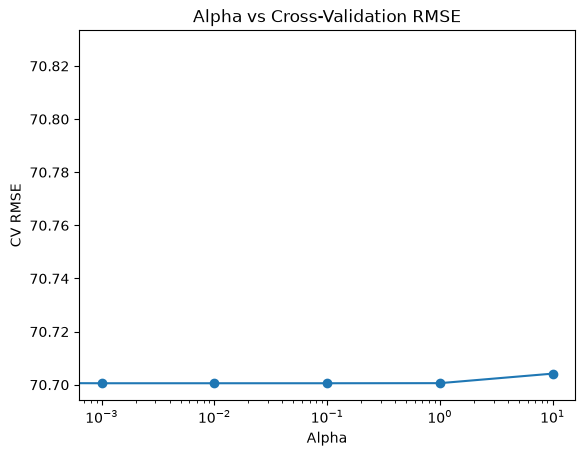

In [81]:
plt.plot(alphas, cv_results.values(), marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("CV RMSE")
plt.title("Alpha vs Cross-Validation RMSE")
plt.show()

In [72]:
final_ridge = Ridge(alpha=0.01)
final_ridge.fit(X_train_scaled, y_train)
y_test_pred = final_ridge.predict(X_test_scaled)

In [80]:
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("Final Ridge Regression")
print("----------------------")
print("Alpha:", 0.01)
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Final Ridge Regression
----------------------
Alpha: 0.01
MAE : 49.4698
MSE : 5065.8783
RMSE: 71.175
R²  : 0.9956


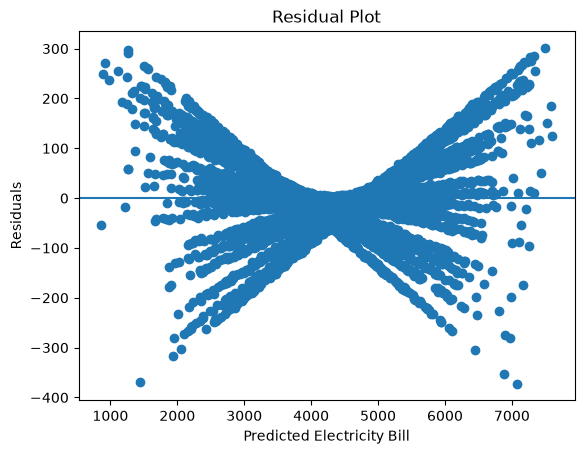

In [79]:
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Electricity Bill")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [75]:
coefficients = final_ridge.coef_
print(coefficients)

[-2.81460374e-01  1.22571320e+00  2.38192340e-01 -6.44126732e-01
 -1.54989030e-01  0.00000000e+00 -1.56739258e-01  1.02849452e+03
  1.43971056e+02 -2.98104737e+01  2.73727095e+01 -4.88721911e+01
 -1.75858262e+01 -4.71123423e+00  1.81236293e+00  2.08874552e+01
  5.53625449e+01  3.41251237e+01  5.98029510e+01  8.40126159e+00
 -1.08870329e+01  4.64278700e+01 -6.36245183e+01 -4.27001075e+01
 -3.60479435e+01 -5.78020915e-03  1.31528767e-01  1.80743070e-01
  6.11612340e-01  1.03276921e-01  3.59191448e-01 -6.68642983e-01
  1.69515772e-01 -4.97372306e-01 -8.03546722e-01 -6.54337294e-02
 -8.54514969e-02 -3.26239288e-01  8.26229383e-01  3.79743119e-02
 -1.69517657e-01 -1.26890992e-01  1.55229097e-02  7.05413307e-01
 -2.20304656e-01 -4.92442267e-01  4.18145650e-01 -6.11240816e-01
  7.09470769e-02  3.05152014e-01  2.79118975e-01 -2.56782756e-01
  7.63860159e-02 -4.53568511e-01  6.12867792e-01 -1.88944173e-01
  8.97173042e-02]


In [55]:
encoded_cols = encoder.get_feature_names_out(categorical_cols)
feature_names = list(numeric_cols) + list(encoded_cols)
for feature, coef in zip(feature_names, final_ridge.coef_):
    print(feature, ":", coef)

Fan : -0.28146037350852965
Refrigerator : 1.2257131952704683
AirConditioner : 0.2381923395688204
Television : -0.6441267322924613
Monitor : -0.1549890301936954
MotorPump : 0.0
Month : -0.15673925764731292
MonthlyHours : 1028.4945195822293
TariffRate : 143.971055613198
City_Ahmedabad : -29.81047374710736
City_Chennai : 27.37270948159713
City_Dahej : -48.87219110606509
City_Faridabad : -17.585826177675237
City_Gurgaon : -4.711234231821635
City_Hyderabad : 1.8123629299065687
City_Kolkata : 20.88745521848459
City_Mumbai : 55.362544884628846
City_Nagpur : 34.12512367685214
City_Navi Mumbai : 59.80295103847016
City_New Delhi : 8.40126159032416
City_Noida : -10.88703292025259
City_Pune : 46.427870019271175
City_Ratnagiri : -63.62451830714749
City_Shimla : -42.70010747446669
City_Vadodara : -36.04794345110344
Company_Adani Power Ltd. : -0.005780209148016256
Company_Bonfiglioli Transmission Pvt. Ltd. : 0.1315287668776379
Company_CESC : 0.18074307044399557
Company_GE T&D India Limited : 0.611612

In [56]:
comparison = pd.DataFrame({
    "Actual Bill": y_test.values,
    "Predicted Bill": y_test_pred
})
print(comparison.head(10))

   Actual Bill  Predicted Bill
0       4233.0     4230.478761
1       4367.4     4373.216954
2       5217.3     5169.033661
3       4048.2     4053.230547
4       3915.0     3935.023352
5       5008.6     5062.444551
6       3942.1     3935.644933
7       4499.2     4557.477312
8       2999.3     3096.432073
9       5100.4     5120.774355


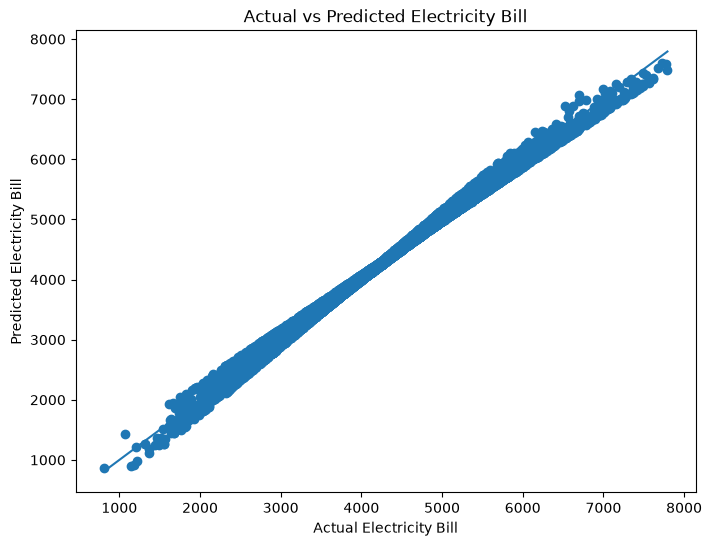

In [78]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Electricity Bill")
plt.ylabel("Predicted Electricity Bill")
plt.title("Actual vs Predicted Electricity Bill")
plt.show()